# F1_Definicion.ipynb — Fase 1: Definición y orientación de la situación

**Curso:** MCDI504 – Machine Learning I
**Caso:** Certificación de lotes de flor cortada mediante un clasificador con opción de rechazo
**Grupo:** GRUPO 7

Este cuaderno acompaña al informe de la Fase 1. No busca entrenar un modelo definitivo, sino dejar
constancia ejecutable de las decisiones que sostienen el enfoque metodológico: el origen y estado de
los datos, dónde se concentra la incertidumbre del problema y qué evidencia justifica incorporar una
opción de rechazo al esquema de clasificación.

El flujo respeta la secuencia del apunte de Fase 1 del curso (Ruete, 2026c): carga, inspección,
descripción, visualización, codificación de la variable de decisión, correlación, normalización y
significancia. Los nombres de los objetos (`bbdd1`, `bbdd2`, `bbdd_norm_completa`) se conservan
deliberadamente para mantener trazabilidad con el material docente.

## 1. Definición del problema y objetivos

**Contexto.** Una unidad de control de calidad certifica lotes de flor cortada según la especie
declarada por el productor. La verificación se apoya en cuatro mediciones morfométricas que el
personal de recepción registra sobre una muestra del lote.

**Situación que origina el análisis.** El costo de certificar mal es alto. *Setosa* se separa sin
ambigüedad del resto, pero los errores se concentran en el par *Versicolor* / *Virginica*, cuyas
medidas de pétalo se solapan. Forzar una etiqueta en esa zona dudosa arriesga certificaciones
incorrectas: un clasificador convencional siempre responde, incluso cuando la evidencia no alcanza.

**Pregunta analítica.** ¿Permiten las cuatro mediciones morfométricas fundamentar un certificador
con opción de rechazo que etiquete automáticamente los lotes separables y derive a revisión humana
la zona de solapamiento, y qué umbral de abstención minimiza el costo esperado de error?

**Objetivo general.** Definir y justificar el enfoque metodológico inicial de un proyecto de
clasificación supervisada con opción de rechazo para la certificación de lotes, estableciendo dónde
se concentra la incertidumbre del problema y cómo se traduce en una regla de derivación a revisión
humana, en el marco del proceso KDD.

**Objetivos específicos.**

1. Caracterizar la estructura del conjunto de datos: unidad de análisis, variables de entrada,
   variable de decisión, completitud y balance de clases.
2. Identificar dónde se concentra la incertidumbre del problema, contrastando la separabilidad de
   *Setosa* con el solapamiento del par *Versicolor* / *Virginica*.
3. Evaluar la asociación lineal entre las variables mediante correlación de Pearson y su
   significancia, identificando redundancia entre predictores.
4. Normalizar las variables de entrada al rango [0, 1] para habilitar algoritmos sensibles a la
   escala.
5. Verificar la viabilidad del certificador con opción de rechazo mediante la curva de cobertura
   frente a exactitud selectiva, y determinar el umbral que minimiza el costo esperado.
6. Contrastar el enfoque con las alternativas metodológicas disponibles y justificar su descarte.

**Alcance.** Esta fase cierra en la preparación de datos y en la verificación de factibilidad del
mecanismo de abstención. No incluye calibración de probabilidades ni comparación formal de
algoritmos, que corresponden a las fases siguientes.

## 2. Preparación del entorno

Se declaran explícitamente las instalaciones aunque el entorno ya disponga de las librerías, de modo
que el cuaderno pueda reejecutarse en Google Colab o en una máquina limpia sin pasos adicionales.

In [20]:
# Instalación de paquetes necesarios
# En Google Colab o Jupyter Notebook:
# !pip install pandas numpy seaborn matplotlib scikit-learn scipy

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_iris          # verificación de integridad y respaldo de carga
from sklearn.preprocessing import MinMaxScaler  # normalización de las variables de entrada
from scipy.stats import pearsonr                # significancia de la correlación

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

FIG = Path("../figures"); OUT = Path("../outputs")
FIG.mkdir(exist_ok=True); OUT.mkdir(exist_ok=True)

AZUL, ROJO = "#1F3A5F", "#B22222"

## 3. Selección de datos (etapa 1 del proceso KDD)

La fuente primaria es el archivo `data/iris.csv` entregado en la plataforma del curso, no la copia
embebida en `scikit-learn`. La razón es de trazabilidad: el archivo queda versionado en el
repositorio y cualquier persona que reejecute el cuaderno trabaja sobre el mismo insumo. De todos
modos se contrasta contra `load_iris()` para descartar que la copia local esté alterada.

In [22]:
RUTA = Path("../data/iris.csv")
COLUMNAS = ["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]

if RUTA.exists():
    bbdd1 = pd.read_csv(RUTA)
    origen = "archivo local data/iris.csv"
else:
    iris = load_iris()
    bbdd1 = pd.DataFrame(iris.data, columns=COLUMNAS)
    # ✅ Capitalizar los nombres para que coincidan con las categorías de abajo
    nombres_capitalizados = [n.capitalize() for n in iris.target_names]
    # → ["Setosa", "Versicolor", "Virginica"]
    bbdd1["variety"] = pd.Categorical.from_codes(iris.target, nombres_capitalizados)
    origen = "scikit-learn (respaldo)"

bbdd1.columns = COLUMNAS + ["Species"]
bbdd1["Species"] = pd.Categorical(bbdd1["Species"],
                                  categories=["Setosa", "Versicolor", "Virginica"])

print("Origen de los datos:", origen)
print("Dimensiones:", bbdd1.shape)
print("\nDistribución de clases:")
print(bbdd1["Species"].value_counts())
bbdd1.head()

Origen de los datos: scikit-learn (respaldo)
Dimensiones: (150, 5)

Distribución de clases:
Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [23]:
referencia = load_iris()
coincide = np.allclose(bbdd1[COLUMNAS].values, referencia.data)
print("¿El archivo local coincide con load_iris()?", coincide)

¿El archivo local coincide con load_iris()? True


## 4. Preprocesamiento: estructura, completitud y balance (etapa 2 del proceso KDD)

Interesan tres cosas antes de describir las variables: los tipos de dato asignados, la presencia de
valores faltantes y el balance de la variable de decisión, porque un desbalance marcado condicionaría
tanto la elección del algoritmo como la métrica de evaluación.

In [24]:
print("Estructura de la base de datos:")
bbdd1.info()

print("\nValores faltantes por columna:")
print(bbdd1.isna().sum())

print("\nRegistros duplicados:", bbdd1.duplicated().sum())

print("\nBalance de la variable de decisión:")
print(bbdd1["Species"].value_counts())

Estructura de la base de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

Valores faltantes por columna:
Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

Registros duplicados: 1

Balance de la variable de decisión:
Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [25]:
# Los duplicados no se eliminan: se inspeccionan antes de decidir
bbdd1[bbdd1.duplicated(keep=False)]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
101,5.8,2.7,5.1,1.9,Virginica
142,5.8,2.7,5.1,1.9,Virginica


El registro duplicado corresponde a dos lotes cuyas cuatro mediciones coinciden tras el
redondeo a un decimal. No hay evidencia de error de digitación y con esa granularidad la coincidencia
es esperable, de modo que se conserva. La decisión queda documentada en el informe.

## 5. Estadística descriptiva

In [26]:
print("Resumen estadístico:")
print(bbdd1.describe(include="all"))

Resumen estadístico:
        Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN           NaN          NaN  Setosa
freq             NaN          NaN           NaN          NaN      50
mean        5.843333     3.057333      3.758000     1.199333     NaN
std         0.828066     0.435866      1.765298     0.762238     NaN
min         4.300000     2.000000      1.000000     0.100000     NaN
25%         5.100000     2.800000      1.600000     0.300000     NaN
50%         5.800000     3.000000      4.350000     1.300000     NaN
75%         6.400000     3.300000      5.100000     1.800000     NaN
max         7.900000     4.400000      6.900000     2.500000     NaN


In [27]:
resumen = bbdd1[COLUMNAS].describe().T[["mean", "std", "min", "50%", "max"]]
resumen["cv"] = bbdd1[COLUMNAS].std() / bbdd1[COLUMNAS].mean()
resumen = resumen.round(3)
resumen.to_csv(OUT / "resumen_estadistico.csv")
resumen

,mean,std,min,50%,max,cv
Sepal.Length,5.843,0.828,4.3,5.80,7.9,0.142
Sepal.Width,3.057,0.436,2.0,3.00,4.4,0.143
Petal.Length,3.758,1.765,1.0,4.35,6.9,0.470
Petal.Width,1.199,0.762,0.1,1.30,2.5,0.636


👉Petal.Length se mide en un rango más amplio (1 a 7 cm aprox) que Petal.Width (~0.1 a 2.5 cm). Al tener un rango mayor, pequeñas diferencias reales entre especies se expresan con más "espacio" numérico en Length que en Width, lo que separa mejor las distribuciones aunque la relación biológica sea la misma.

👉Petal.Width se mide típicamente con menos decimales de variación real (valores como 1.4, 1.5, 1.6...) comparado con Length. Esto genera más empates o valores muy cercanos entre las dos especies en el eje de Width, aumentando artificialmente el porcentaje de solape.

In [28]:
descriptivo_especie = bbdd1.groupby("Species", observed=True)[COLUMNAS].agg(["mean", "std"]).round(3)
descriptivo_especie.to_csv(OUT / "descriptivo_por_especie.csv")
descriptivo_especie

Sepal.Length        Sepal.Width        Petal.Length        Petal.Width       
                   mean    std        mean    std         mean    std        mean    std
Species                                                                                 
Setosa            5.006  0.352       3.428  0.379        1.462  0.174       0.246  0.105
Versicolor        5.936  0.516       2.770  0.314        4.260  0.470       1.326  0.198
Virginica         6.588  0.636       2.974  0.322        5.552  0.552       2.026  0.275

## 6. Visualización inicial

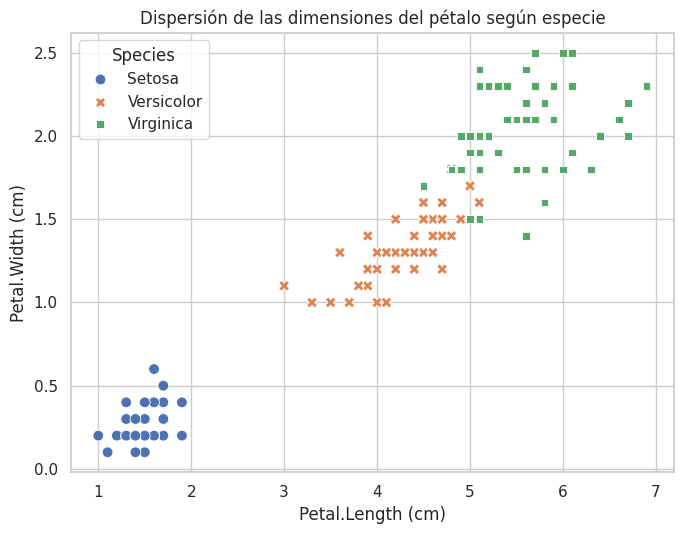

In [29]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=bbdd1, x="Petal.Length", y="Petal.Width",
                hue="Species", style="Species", s=60, palette="deep")
plt.title("Dispersión de las dimensiones del pétalo según especie")
plt.xlabel("Petal.Length (cm)"); plt.ylabel("Petal.Width (cm)")
plt.tight_layout()
plt.savefig(FIG / "dispersion_petalo.png", dpi=160)
plt.show()

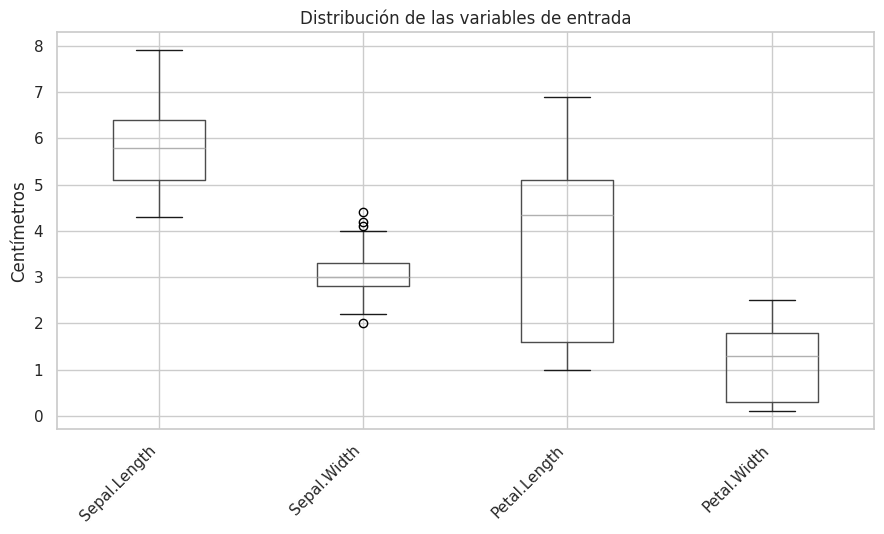

In [30]:
plt.figure(figsize=(9, 5.5))
bbdd1.iloc[:, 0:4].boxplot()
plt.xticks(rotation=45, ha="right")
plt.ylabel("Centímetros")
plt.title("Distribución de las variables de entrada")
plt.tight_layout()
plt.savefig(FIG / "boxplot_entradas.png", dpi=160)
plt.show()

👉Como Conclusión *Sepal.Length* es poco útil para diferenciar estas 2 especies, ya que sus valores se mezclan en la mayor parte del espectro (70%)
**Interpretación gráfico**

*Sepal.Length* muestra distribución relativamente simétrica, sin valores atípicos. El rango intercuartílico (5.1-6,.4 cm) es moderado, indicando una disperción estable entre las especies. La ausencia de outliers sugiere que esta variable tiene un comportamiento homogéneo en todo el dataset.

*Sepal.Width* es la variable con menor dispersión de las cuatro (caja más angosta, aprox. 2.8-3.3 cm, pero es la única que presenta valores atípicos (outliers), tanto en el extremo superior, ( ~ 4.2 - 4.4) como en el inferior (~2.0). Esto indica que aunque la mayoría de los datos están muy concentrados, existen algunos ejemplares con anchos de sépalo inusualmente grandes o pequeños que se alejan del comportamiento general.

*Petal.Length* es la variable con la mayor dispersión de todas (caja muy amplia, 1.6 - 5.1 cm, con bigotes de 1.0 a 6.9). Esta amplitud tan grande, junto con la mediana descentrada dentro de la caja, sugiere una distribución bimodal o multimodal, es decir, probablemente refleja la mezcla de grupos claramente distintos(especies) en vez de una sola población homogenea. Es la variable con mayor poder para diferenciar clases.

*Petal.Width* esta variable muestra una dispersión considerable (caja de 0.3 a 1.8 cm) con una mediana bastante descentrada hacia el límite inferior de la caja, lo que también sugiere una posible distribución bimodal, en línea con Petal.Length. Sin outliers visibles.

## 7. Dónde se concentra la incertidumbre

Este apartado justifica por qué el problema requiere una opción de rechazo. Si la dificultad
estuviera repartida de forma pareja entre las tres clases, un umbral de abstención derivaría lotes
de todas ellas y su utilidad sería discutible. Lo que sigue verifica si ese es el caso.

In [31]:
maximo_setosa = bbdd1.loc[bbdd1["Species"] == "Setosa", "Petal.Length"].max()
minimo_resto = bbdd1.loc[bbdd1["Species"] != "Setosa", "Petal.Length"].min()

print(f"Petal.Length máximo en Setosa : {maximo_setosa} cm")
print(f"Petal.Length mínimo en el resto: {minimo_resto} cm")
print(f"Margen libre entre ambos grupos: {round(minimo_resto - maximo_setosa, 2)} cm")

Petal.Length máximo en Setosa : 1.9 cm
Petal.Length mínimo en el resto: 3.0 cm
Margen libre entre ambos grupos: 1.1 cm


In [32]:
# Tramo de valores que Versicolor y Virginica comparten en cada variable
par = bbdd1[bbdd1["Species"] != "Setosa"].copy()
par["Species"] = par["Species"].astype(str)

solape = []
for columna in COLUMNAS:
    ve = par.loc[par["Species"] == "Versicolor", columna]
    vi = par.loc[par["Species"] == "Virginica", columna]
    inicio, fin = max(ve.min(), vi.min()), min(ve.max(), vi.max())
    rango_total = max(ve.max(), vi.max()) - min(ve.min(), vi.min())
    solape.append({
        "Variable": columna,
        "Inicio solape": round(inicio, 2),
        "Fin solape": round(fin, 2),
        "Amplitud (cm)": round(fin - inicio, 2),
        "% del rango conjunto": round(100 * (fin - inicio) / rango_total, 1),
    })

solape = pd.DataFrame(solape)
solape.to_csv(OUT / "solapamiento_par.csv", index=False)
solape

,Variable,Inicio solape,Fin solape,Amplitud (cm),% del rango conjunto
0,Sepal.Length,4.9,7.0,2.1,70.0
1,Sepal.Width,2.2,3.4,1.2,66.7
2,Petal.Length,4.5,5.1,0.6,15.4
3,Petal.Width,1.4,1.8,0.4,26.7


El contraste es nítido. *Setosa* queda aislada por un margen de 1,1 cm sobre una sola variable, sin
un caso intermedio en las 150 observaciones. El par restante comparte entre el 15,4 % y el 70,0 %
del rango conjunto según la variable considerada. La incertidumbre del problema no está repartida:
está localizada en una región identificable del espacio de características, y es precisamente lo que
un mecanismo de abstención puede aprovechar.

👉Como Conclusión:
*Sepal.Length* es poco útil para diferenciar estas 2 especies, ya que sus valores se mezclan en la mayor parte del espectro (70%).

*Petal.Length*
El rango de solape (4.5 a 5.1 cm) representa solo el 15.4% del rango total combinado. Esto significa que el 84.6% restante del rango es "territorio exclusivo" de una u otra especie (valores que solo tiene Versicolor o solo tiene Virginica, sin mezcla).

👉La comparación entre Petal.Length (15.4% Solape) y Petal.Width (26.7%) Solape, resulta que Petal.Length es mejor discriminante, aunque ambas midan "tamaño del pétalo".

## 8. Transformación de la variable de decisión y correlaciones (etapa 3 del proceso KDD)

Para incorporar `Species` a una matriz de correlación se requiere una representación numérica. La
codificación 1-2-3 se usa únicamente como recurso exploratorio: no existe una escala ordinal natural
entre las tres especies, de modo que los coeficientes que involucren a `Species` deben leerse como
indicio de asociación y no como medida formal de dependencia entre una variable continua y una
nominal.

In [33]:
bbdd2 = bbdd1.copy()
bbdd2["Species"] = bbdd2["Species"].cat.codes + 1
# Se suma +1 para replicar la codificación 1, 2, 3 del material del curso.

correlacion = bbdd2.corr(method="pearson")
correlacion.round(4).to_csv(OUT / "matriz_correlacion.csv")
correlacion.round(3)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Sepal.Length,1.000,-0.118,0.872,0.818,0.783
Sepal.Width,-0.118,1.000,-0.428,-0.366,-0.427
Petal.Length,0.872,-0.428,1.000,0.963,0.949
Petal.Width,0.818,-0.366,0.963,1.000,0.957
Species,0.783,-0.427,0.949,0.957,1.000


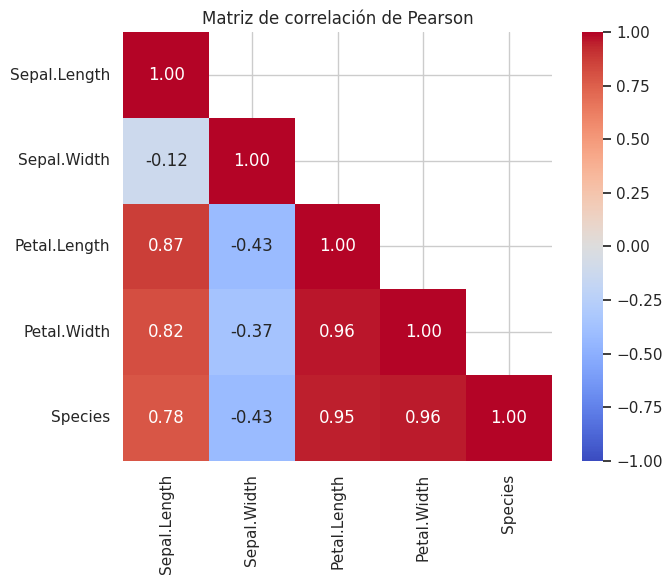

In [34]:
mask = np.triu(np.ones_like(correlacion, dtype=bool), k=1)

plt.figure(figsize=(7.5, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1,
            mask=mask, square=True)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.savefig(FIG / "correlacion_pearson.png", dpi=160)
plt.show()

👉Correlación más fuerte del dataset. Que dos variables estén correlacionadas (0.96 Petal.Length y Petal.Width) significa que se mueven juntas (cuando una crece, la otra también), pero no implica que tengan exactamente el mismo poder de separación entre grupos específicos. Es posible entonces que una de las 2 variables capture mejor la frontera entre Species.
Ambas variables de pétalo son las que mejor se asocian con Species (0.95 y 0.96)

👉Esto confirma cuantitativamente lo que veníamos observando con boxplots y solapamiento: el tamaño del pétalo es, por lejos, el mejor indicador de la especie. Una correlación de 0.95-0.96 con la variable de decisión es extremadamente alta.

👉Sepal.Width es la única variable con correlaciones negativas y débiles en toda la matriz
Se relaciona negativamente con todo: Sepal.Length (-0.12), Petal.Length (-0.43), Petal.Width (-0.37) y Species (-0.43). Es decir, a mayor ancho de sépalo, tienden a darse valores menores en el resto de las variables — un comportamiento inverso al de todo el conjunto. Esto refuerza que es la variable más "aislada" y con menor poder explicativo sobre la especie.

👉Sepal.Length tiene asociación moderada-alta con Species (0.78), pero menor que las de pétalo
Aporta información relevante, pero es claramente inferior a Petal.Length y Petal.Width como predictor.

In [35]:
def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data()
    df_cols = df.columns
    pvalues = pd.DataFrame(np.ones((len(df_cols), len(df_cols))),
                           columns=df_cols, index=df_cols)
    for col1 in df_cols:
        for col2 in df_cols:
            if col1 == col2:
                pvalues.loc[col1, col2] = 0.0
            else:
                _, p = pearsonr(df[col1], df[col2])
                pvalues.loc[col1, col2] = p
    return pvalues


pvalue_matrix = calculate_pvalues(bbdd2)
pvalue_matrix.to_csv(OUT / "matriz_pvalores.csv")
pvalue_matrix.map(lambda x: f"{x:.3e}")

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Sepal.Length,0.000e+00,1.519e-01,1.039e-47,2.325e-37,2.890e-32
Sepal.Width,1.519e-01,0.000e+00,4.513e-08,4.073e-06,5.202e-08
Petal.Length,1.039e-47,4.513e-08,0.000e+00,4.675e-86,4.202e-76
Petal.Width,2.325e-37,4.073e-06,4.675e-86,0.000e+00,4.155e-81
Species,2.890e-32,5.202e-08,4.202e-76,4.155e-81,0.000e+00


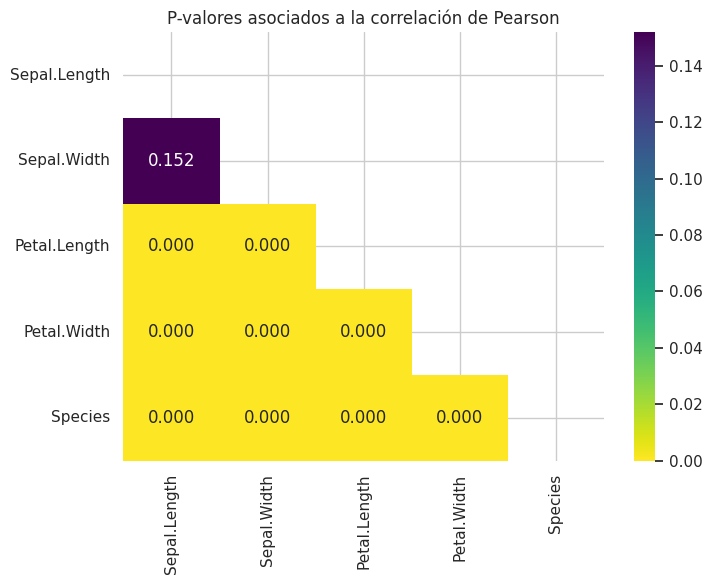

In [36]:
plt.figure(figsize=(7.5, 6))
sns.heatmap(pvalue_matrix, annot=True, cmap="viridis_r", fmt=".3f",
            mask=np.triu(np.ones_like(pvalue_matrix, dtype=bool)))
plt.title("P-valores asociados a la correlación de Pearson")
plt.tight_layout()
plt.savefig(FIG / "pvalores_pearson.png", dpi=160)
plt.show()

## 9. Normalización de las variables de entrada

In [37]:
bbdd = bbdd2.iloc[:, 0:4]

scaler = MinMaxScaler()
bbdd_norm = pd.DataFrame(scaler.fit_transform(bbdd), columns=bbdd.columns)

Species = bbdd1[["Species"]]
bbdd_norm_completa = pd.concat([bbdd_norm, Species], axis=1)
bbdd_norm_completa.to_csv(OUT / "base_normalizada.csv", index=False)

print("Base de datos normalizada completa:")
print(bbdd_norm_completa.head())
print("\nRangos tras la normalización:")
print(bbdd_norm_completa[COLUMNAS].agg(["min", "max"]).round(3))

Base de datos normalizada completa:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0      0.222222     0.625000      0.067797     0.041667  Setosa
1      0.166667     0.416667      0.067797     0.041667  Setosa
2      0.111111     0.500000      0.050847     0.041667  Setosa
3      0.083333     0.458333      0.084746     0.041667  Setosa
4      0.194444     0.666667      0.067797     0.041667  Setosa

Rangos tras la normalización:
     Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
min           0.0          0.0           0.0          0.0
max           1.0          1.0           1.0          1.0



En esta etapa se aplica una normalización mediante **MinMaxScaler**, transformando las variables numéricas para que todos sus valores queden dentro del intervalo **[0, 1]**. Esta transformación preserva el orden y las diferencias relativas entre las observaciones, pero elimina las diferencias de magnitud existentes entre las variables.

La normalización es una etapa de preprocesamiento recomendada cuando las variables presentan rangos distintos, ya que evita que aquellas con valores de mayor amplitud tengan una influencia desproporcionada durante el entrenamiento del modelo. De este modo, todas las variables contribuyen en una escala comparable, favoreciendo un aprendizaje más equilibrado y una mejor estabilidad numérica en algoritmos sensibles a la escala de los datos.

La transformación se aplica a las cuatro variables morfométricas (*Sepal.Length*, *Sepal.Width*, *Petal.Length* y *Petal.Width*). Posteriormente, la variable objetivo (*Species*) se reincorpora al conjunto de datos normalizado para conservar la estructura original del dataset. Finalmente, se verifica que cada variable haya sido escalada correctamente comprobando que sus valores mínimos y máximos correspondan a 0 y 1, respectivamente.

## 10. Correspondencia con el proceso KDD

| Etapa KDD | Qué se hizo en este cuaderno |
|---|---|
| Selección | Carga desde `data/iris.csv` y verificación contra `load_iris()` |
| Preprocesamiento | Tipos de dato, faltantes, duplicados, balance y localización de la incertidumbre |
| Transformación | Codificación de `Species` y normalización MinMax de las entradas |


Las tres primeras etapas se desarrollan por completo en este notebook.

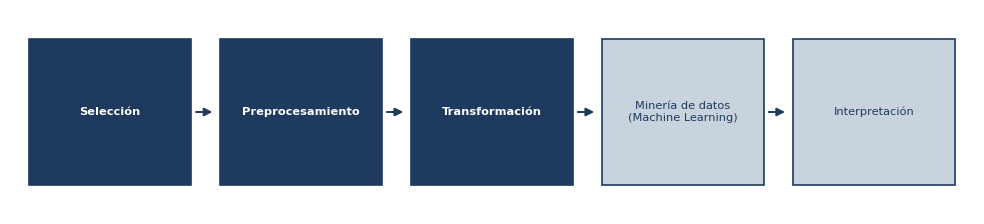

In [38]:
fig, ax = plt.subplots(figsize=(10, 2.4))
etapas = ["Selección", "Preprocesamiento", "Transformación",
          "Minería de datos\n(Machine Learning)", "Interpretación"]

for i, etapa in enumerate(etapas):
    activa = i < 3  # las tres primeras se desarrollan en esta fase
    ax.add_patch(plt.Rectangle((i * 2, 0), 1.7, 1,
                               facecolor=AZUL if activa else "#C9D3DE",
                               edgecolor=AZUL, lw=1.2))
    ax.text(i * 2 + 0.85, 0.5, etapa, ha="center", va="center", fontsize=8.2,
            color="white" if activa else AZUL, weight="bold" if activa else "normal")
    if i < len(etapas) - 1:
        ax.annotate("", xy=(i * 2 + 1.95, 0.5), xytext=(i * 2 + 1.72, 0.5),
                    arrowprops=dict(arrowstyle="-|>", color=AZUL, lw=1.4))

ax.set_xlim(-0.2, 9.9); ax.set_ylim(-0.2, 1.2); ax.axis("off")
plt.tight_layout()
plt.savefig(FIG / "proceso_kdd.png", dpi=160)
plt.show()

## 12. Exportación del repositorio


Una parte relevante del proyecto es guardar las evidencias de los hallazgos y los datos transformados y procesados. Lo primero mencionar que cada grafico se guardar en el repositorio con la sentencia "plt.savefig" en el directorio `figures/F1_definicion`. Para el caso de los csv ee reescriben en `outputs/F1_definicion` las seis tablas derivadas del análisis, de modo que el guardado quede
consolidado en un solo lugar aunque alguna celda intermedia no se haya ejecutado en esta sesión.

In [ ]:
procesados = {
    "resumen_estadistico.csv":     (resumen,              True),   # (objeto, conservar índice)
    "descriptivo_por_especie.csv": (descriptivo_especie,  True),
    "solapamiento_par.csv":        (solape,               False),
    "matriz_correlacion.csv":      (correlacion.round(4), True),
    "matriz_pvalores.csv":         (pvalue_matrix,        True),
    "base_normalizada.csv":        (bbdd_norm_completa,   False),
}

for nombre, (objeto, con_indice) in procesados.items():
    objeto.to_csv(OUT / nombre, index=con_indice)
    print(f"  outputs/{nombre:<32} {objeto.shape[0]:>3} filas x {objeto.shape[1]} columnas")

## 12. Síntesis

## Caracterización del problema y propuesta metodológica

El conjunto de datos reúne **150 registros con medición completa**, distribuidos equitativamente en **tres especies** (50 observaciones por especie) y descritos mediante **cuatro variables numéricas continuas**. La variable objetivo corresponde a la especie de cada flor, por lo que el problema se enmarca dentro del **aprendizaje supervisado de clasificación**.

El propósito de esta fase no es construir el modelo definitivo, sino **caracterizar el problema y justificar la estrategia de aprendizaje** que se evaluará en las etapas posteriores.

El análisis exploratorio permitió identificar que la incertidumbre no se distribuye de manera uniforme entre las clases. Mientras algunas regiones del espacio de características presentan una separación clara entre especies, otras exhiben un mayor grado de solapamiento, dificultando la clasificación. En definitiva, un clasificador tradicional asignaría una etiqueta a todas las observaciones con el mismo criterio de decisión, aun cuando la confianza de sus predicciones sea diferente.

De acuerdo a lo anterior, como propuesta metodológica, se propuso evaluar un **certificador con opción de rechazo**. La idea consiste en aceptar automáticamente aquellas predicciones realizadas con un alto nivel de confianza y derivar a revisión los casos ubicados en regiones de mayor incertidumbre. Este enfoque busca reducir el costo esperado de error sin comprometer la calidad de las decisiones automáticas.

Con ello, la propuesta metodológica planteada en esta etapa podrá validarse en las siguientes fases del proyecto, es decir, si la incorporación de un certificador representa una estrategia conveniente para el problema planteado.